# Modélisation

## Importation et demarrage spark

In [4]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import col, count, when, percentile_approx

sns.set_theme(style='whitegrid', font_scale=1.1)
PALETTE = ['#3498db', '#e74c3c']

spark = (
    SparkSession.builder
    .appName('04_modelisation_immobilier')
    .master('local[*]')
    .config('spark.ui.enabled', 'false')
    .config('spark.sql.shuffle.partitions', '8')
    .getOrCreate()
)

spark.sparkContext.setLogLevel('ERROR')
print('Spark démarré, version:', spark.version)

Spark démarré, version: 4.1.1


In [ ]:
##  1. Chargement des données

In [5]:
df = spark.read.parquet('../data/clean')

In [6]:
df.count()

5336

## Analyse exploratoire - Variable surface

In [7]:
df.select('surface').summary().show()

+-------+-----------------+
|summary|          surface|
+-------+-----------------+
|  count|             5336|
|   mean|81.92859820089954|
| stddev|55.84448515472042|
|    min|              5.0|
|    25%|             47.0|
|    50%|             70.0|
|    75%|            101.0|
|    max|           1233.0|
+-------+-----------------+



In [8]:
# Skewness et kurtosis
stats_surface = df.select(
    F.skewness('surface').alias('skewness'),
    F.kurtosis('surface').alias('kurtosis')
).collect()[0]

print(f"Skewness (asymétrie) : {stats_surface['skewness']:.4f}")
print(f"Kurtosis (aplatissement) : {stats_surface['kurtosis']:.4f}")

Skewness (asymétrie) : 3.9755
Kurtosis (aplatissement) : 47.5261


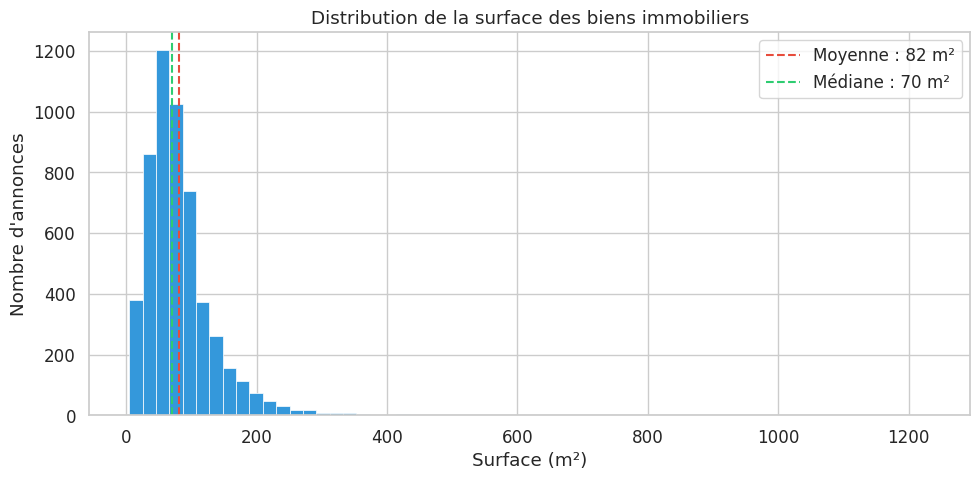

In [9]:
surface_pd = df.select('surface').dropna().toPandas()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(surface_pd['surface'], bins=60, color='#3498db', edgecolor='white', linewidth=0.5)

mean_val   = surface_pd['surface'].mean()
median_val = surface_pd['surface'].median()

ax.axvline(mean_val,   color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Moyenne : {mean_val:.0f} m²')
ax.axvline(median_val, color='#2ecc71', linestyle='--', linewidth=1.5, label=f'Médiane : {median_val:.0f} m²')

ax.set_xlabel('Surface (m²)')
ax.set_ylabel('Nombre d\'annonces')
ax.set_title('Distribution de la surface des biens immobiliers')
ax.legend()
plt.tight_layout()
plt.show()

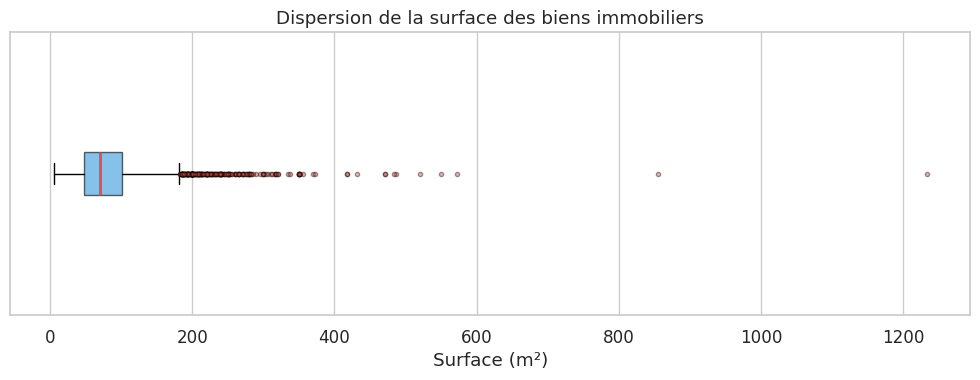

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.boxplot(surface_pd['surface'].dropna(), vert=False, patch_artist=True,
           boxprops=dict(facecolor='#3498db', alpha=0.6),
           medianprops=dict(color='#e74c3c', linewidth=2),
           flierprops=dict(marker='o', markerfacecolor='#e74c3c', markersize=3, alpha=0.4))

ax.set_xlabel('Surface (m²)')
ax.set_title('Dispersion de la surface des biens immobiliers')
ax.yaxis.set_visible(False)
plt.tight_layout()
plt.show()

- On voit que la plupart des biens sont dans la zone 47m² à 101m², nous avons quelques biens très grandes qui tirent la moyenne vers la haut, cela montre que la distribution n'est pas symetrique on a un etalement vers la droite. 
- Le minimum parait bizzare 5m2 avec le type de bien qu'on à. nous allons verifier et supprimer si c'est incoherent. 

In [12]:
df.select('surface', 'type_bien', 'prix').orderBy('surface').show(30, truncate=False)

+-------+-----------+--------+
|surface|type_bien  |prix    |
+-------+-----------+--------+
|5.0    |appartement|47000.0 |
|7.0    |appartement|100000.0|
|7.0    |appartement|70000.0 |
|7.0    |appartement|69500.0 |
|7.0    |appartement|55000.0 |
|8.0    |studio     |80000.0 |
|8.0    |studio     |133000.0|
|8.0    |appartement|109900.0|
|8.0    |appartement|89900.0 |
|8.0    |studio     |222000.0|
|8.0    |appartement|94000.0 |
|9.0    |appartement|53000.0 |
|9.0    |appartement|99000.0 |
|9.0    |appartement|70000.0 |
|9.0    |studio     |80000.0 |
|9.0    |appartement|88000.0 |
|9.0    |appartement|87000.0 |
|9.0    |appartement|120000.0|
|9.0    |appartement|135000.0|
|10.0   |studio     |105000.0|
|10.0   |appartement|180000.0|
|10.0   |appartement|105000.0|
|11.0   |appartement|75000.0 |
|11.0   |appartement|17000.0 |
|11.0   |studio     |133000.0|
|11.0   |appartement|99000.0 |
|11.0   |studio     |134000.0|
|11.0   |studio     |140000.0|
|11.0   |appartement|130000.0|
|12.0   

On voit des biens avec des surfaces très petites, entre 5 m² et 12 m². Ces valeurs sont bizarres par rapport au reste des annonces. Ce n’est pas forcément faux, mais ça peut venir d’une erreur ou d’un bien très particulier. Comme ça peut fausser le modèle, on décide de ne pas les garder dans le premier jeu de données pour le machine learning

In [13]:
df = df.filter(F.col("surface") >= 12)